# SVC Classification: From a 2D Boundary to a More Flexible Decision Surface

## 1. The Situation: A Story

Maya works on a quality-control system. Every item is measured using two values:

- `X1`: the first measurement
- `X2`: the second measurement

Some items belong to group `0`, and some belong to group `1`. Maya receives a new item and wants the computer to answer:

```text
Does this item belong to group 0 or group 1?
```

At first, Maya plots the measurements on a 2D chart. Each item becomes one point at `(X1, X2)`. The points have different labels, so Maya asks whether a line can separate the two groups.

This notebook follows Maya's investigation from the first simple model to more flexible SVC approaches.

## 2. What Problem Are We Solving?

This is a **binary classification** problem.

We have:

```text
Input features: X1 and X2
Target label:   Y
Possible labels: 0 or 1
```

The goal is to learn this relationship:

```text
(X1, X2) -> predict Y
```

In the notebook, the labels are created as follows:

```python
df1["Y"] = 0
df2["Y"] = 1
```

The combined table `dff` contains the measurements and their known answers. The model learns from the training records and is then tested on records that were kept aside.

## 3. The Initial Approach

The first approach uses the original two features directly:

```python
x = dff[["X1", "X2"]]
y = dff["Y"]
```

Then the data is split into training and test parts:

```python
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.1,
    random_state=0
)
```

The SVC learns from:

```python
clff.fit(X_train, y_train)
```

and predicts labels for:

```python
clff.predict(X_test)
```

### First visualization

In a 2D chart, `X1` and `X2` are the two axes. The color shows the known class label `Y`. The model tries to find a boundary between the colored groups.

## 4. What Is the Problem with the Initial Approach?

The initial model uses a linear boundary:

```python
SVC(kernel="linear")
```

A linear boundary is useful when one straight line can separate the groups. But real data is often mixed, curved, or arranged in a pattern that cannot be separated well by one straight line.

The problem is not that SVC failed to run. The problem is that the chosen boundary may be too simple for the shape of the data.

There is another important issue in a small experiment like this: the dataset has only 13 records. With `test_size=0.1`, only 2 records are used for testing. Therefore, one correct or incorrect prediction changes the accuracy by 50 percentage points. The score helps us understand the process, but it is not a reliable real-world performance estimate.

## 5. Solution A: Create Better Features Manually

Maya can give the linear SVC additional information by creating polynomial features:

```python
dff["X1_S"] = dff["X1"] ** 2
dff["X2_S"] = dff["X2"] ** 2
dff["X1X2"] = dff["X1"] * dff["X2"]
```

The model input becomes:

```text
X1, X2, X1_S, X2_S, X1X2
```

The SVC still uses a linear kernel, but it now finds a linear boundary in this expanded feature space:

```text
(X1, X2, X1_S, X2_S, X1X2) -> predict Y
```

This is why a linear model can sometimes represent a more complicated boundary after feature engineering. The transformation is performed explicitly by us.

## 6. Solution B: Use a Polynomial Kernel

Instead of creating the polynomial columns ourselves, Maya can give SVC the original features and ask it to calculate polynomial relationships internally:

```python
svc_poly = SVC(kernel="poly", degree=2)
svc_poly.fit(X_train_raw, y_train_raw)
```

Here:

```text
Input given by us: X1 and X2
Polynomial relationships: calculated internally by SVC
```

This is related to manual feature engineering, but the two approaches are not automatically identical. The polynomial kernel also depends on parameters such as `degree`, `gamma`, `coef0`, and `C`.

## 7. How the Solutions Work in Real Life

Imagine a bank deciding whether a transaction is normal or suspicious.

The raw features might be:

```text
transaction amount
number of transactions in one hour
```

A simple linear model may struggle because suspicious behavior may depend on combinations such as:

```text
amount squared
transaction count squared
amount multiplied by transaction count
```

An engineer can either:

1. Create those derived features explicitly and train a linear model, or
2. Use a polynomial kernel so the SVC calculates polynomial relationships internally.

In a production system, the team would also use many more records, a carefully chosen validation strategy, feature scaling, monitoring, and a test set large enough to support a trustworthy accuracy estimate.

## 8. What the 2D and 3D Pictures Mean

A 2D plot shows two input features:

```text
(X1, X2)
```

The existing 3D label plot shows:

```text
(X1, X2, Y)
```

That is useful for visualization, but `Y` is the target, not an input feature.

A genuine 3D feature plot can show:

```text
(X1, X2, X1_S)
```

The manual model actually uses five feature dimensions, so no ordinary 2D or 3D picture can show its complete feature space at once.

The central distinction is:

```text
Visualization dimensions = how we look at the data
Feature dimensions      = what the model uses to predict
```

The cells below now implement this story step by step: create the groups, assign labels, combine the data, split training and test records, train SVC models, compare predictions, and visualize the data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
X1 = np.array([[1,5], [2,3],[3,7],[4,1],[5,7],[6,2],[7,6],[8,4]])

### Why these imports and arrays come first

```python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
```

- `numpy` creates and manipulates numeric arrays.
- `pandas` stores the measurements in labelled tables.
- `matplotlib.pyplot` draws the first static plots.

The array `X1` contains eight observations. Each inner list is one observation with two values:

```text
[ X1_value, X2_value ]
```

So `X1` has shape `(8, 2)`: 8 rows and 2 measurements per row. At this point there are no labels yet; we only have raw observations for the first group.

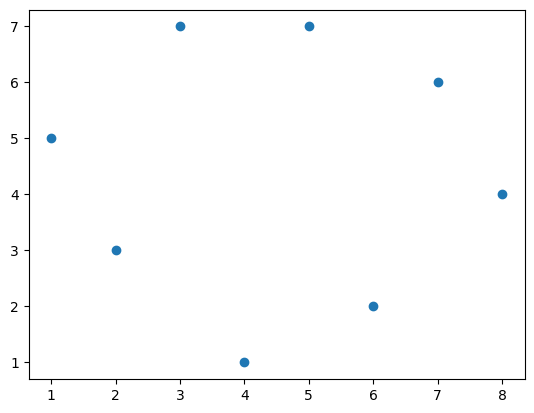

In [2]:
plt.scatter(X1[:,0],X1[:,1])
plt.show()

### Visualizing the first group

```python
X1[:, 0]
X1[:, 1]
```

The colon means "take every row". The number after the comma selects a column: column `0` is the first measurement and column `1` is the second. A scatter plot places each row at `(X1[:, 0], X1[:, 1])`, so one dot represents one observation from group 0.

In [3]:
X2 = np.array([[3,3], [4,4],[5,5],[3,4],[4,5]])

### Creating the second group

`X2` has five more observations with the same two measurements. Keeping the two groups in separate arrays initially makes the teaching problem visible: we can plot each group independently before assigning the labels that a classifier needs.

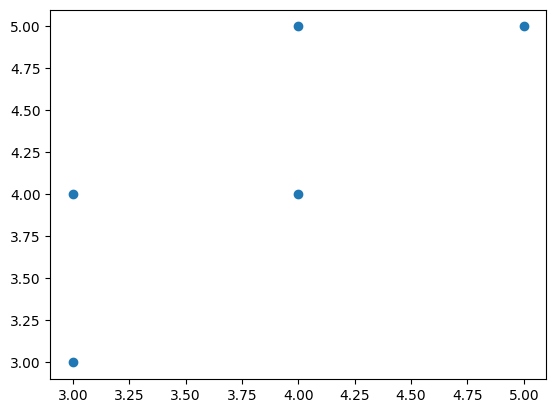

In [4]:
plt.scatter(X2[:,0],X2[:,1])
plt.show()

### Visualizing the second group

The second scatter plot uses the same coordinate logic, but for `X2`. Comparing the two plots lets us ask the key modeling question: do the two groups occupy visibly different regions, or are their points mixed together?

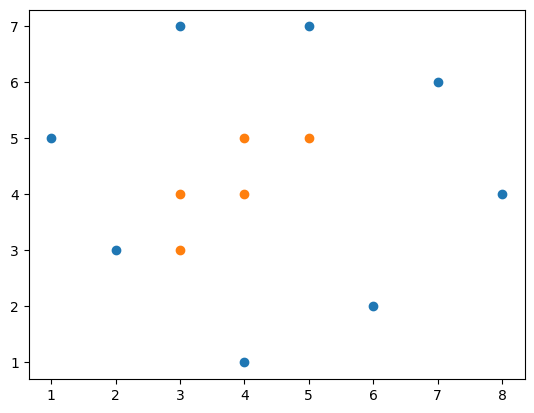

In [5]:
plt.scatter(X1[:,0],X1[:,1])
plt.scatter(X2[:,0],X2[:,1])

### Overlaying the groups

Putting both scatters on one axes gives the first useful visual comparison. At this stage the dots have no class column attached yet; the code knows that they came from different arrays, but a machine-learning estimator needs one explicit target vector such as `Y = 0` or `Y = 1`.

In [6]:
x,y=X1[:,0],X1[:,1]

### Naming the coordinates

```python
x, y = X1[:, 0], X1[:, 1]
```

This unpacks the two columns of `X1` into separate one-dimensional arrays. The lowercase names are temporary coordinate arrays; they are not yet the machine-learning target `y` used later. The next cells turn these coordinates into named DataFrame columns so the meaning of each value is explicit.

In [7]:
u,v=X2[:,0],X2[:,1]

The same unpacking is performed for `X2`. `u` and `v` are simply the first and second measurements of the second group. The different variable names prevent us from accidentally mixing group 1 coordinates with group 2 coordinates before the tables are built.

In [8]:
df1 =pd.DataFrame(np.vstack([x,y]).T,columns=['X1','X2'])
df1['Y']=0
df1

,X1,X2,Y
0,1,5,0
1,2,3,0
2,3,7,0
3,4,1,0
4,5,7,0
5,6,2,0
6,7,6,0
7,8,4,0


### Turning group 0 into a labelled table

```python
df1 = pd.DataFrame(np.vstack([x, y]).T, columns=["X1", "X2"])
```

- `np.vstack([x, y])` stacks the two coordinate arrays vertically.
- `.T` transposes the result so each observation becomes one row.
- `columns=["X1", "X2"]` gives the measurements meaningful names.

Then:

```python
df1["Y"] = 0
```

adds the target column. Every row came from the first group, so every row receives label `0`. This is not a prediction; it is the known training truth that we are giving the model.

In [9]:
df2 =pd.DataFrame(np.vstack([u,v]).T,columns=['X1','X2'])
df2['Y']=1
df2

,X1,X2,Y
0,3,3,1
1,4,4,1
2,5,5,1
3,3,4,1
4,4,5,1


### Turning group 1 into a labelled table

The second table uses the same construction, but its target assignment is `1`. The identical column names are intentional: both tables must have the same schema before they can be combined row by row.

In [13]:
dff = pd.concat([df1, df2], ignore_index=True)

### Combining the labelled groups

```python
dff = pd.concat([df1, df2], ignore_index=True)
```

`pd.concat` performs a row-wise union of the two tables. `ignore_index=True` creates a fresh index from `0` to `12`; it prevents the original group-specific indexes from being mistaken for meaningful identifiers. The result is now one supervised-learning dataset with feature columns `X1`, `X2`, and target column `Y`.

In [14]:
dff

,X1,X2,Y
0,1,5,0
1,2,3,0
2,3,7,0
3,4,1,0
4,5,7,0
5,6,2,0
6,7,6,0
7,8,4,0
8,3,3,1
9,4,4,1


Displaying `dff` at this point is a checkpoint. We should verify that the table has 13 rows, two measurement columns, and one target column before training. In a real project, this kind of inspection catches missing values, wrong labels, and unexpected column types before they reach the estimator.

In [15]:
x = dff[['X1','X2']]
y = dff['Y']

### Separating inputs from the answer

```python
x = dff[["X1", "X2"]]
y = dff["Y"]
```

The double brackets select a DataFrame containing the input columns. The single brackets select one Series containing the target. This distinction is fundamental:

```text
X / x = evidence available before prediction
y / Y = answer used during training and evaluation
```

The target must not be included in `x`; doing so would let the model see the answer while trying to learn it.

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.1, random_state=0)

### Holding out unseen records

```python
train_test_split(x, y, test_size=0.1, random_state=0)
```

This function shuffles the matching rows of `x` and `y` together, then returns four aligned objects:

- `X_train`, `y_train`: records and labels used to learn the boundary
- `X_test`, `y_test`: records and labels reserved for checking the learned boundary

`test_size=0.1` asks for 10% of the 13 records, which becomes 2 test records. `random_state=0` makes the shuffle repeatable, so the same rows are selected each time we rerun the notebook.

## Training and Test Records

The complete dataset contains **13 records**:

- `X1` contributes 8 records, labelled `0`.
- `X2` contributes 5 records, labelled `1`.

The data is split using:

```python
train_test_split(x, y, test_size=0.1, random_state=0)
```

Because `test_size=0.1`, the model receives:

- **11 training records** through `X_train` and `y_train`
- **2 test records** through `X_test` and `y_test`

The model is trained only with `X_train` and `y_train`. The test records in `X_test` are passed later to `predict()` so that we can evaluate the model on data it did not use during training.

To inspect the test records before prediction, run:

```python
print("Number of test records:", len(X_test))
print(pd.concat([X_test, y_test.rename("actual_label")], axis=1))
```

In [19]:
from sklearn.svm import SVC
clff = SVC(kernel="linear")
clff.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Training a linear SVC

```python
clff = SVC(kernel="linear")
clff.fit(X_train, y_train)
```

`SVC(...)` creates the estimator and `kernel="linear"` asks it to search for a flat separating boundary. The `fit` method is the learning step: it uses the training features and their known labels to choose the boundary. The test records are deliberately absent from `fit`, otherwise evaluation would no longer measure performance on unseen data.

In [28]:
y_pred = clff.predict(X_test)

print(y_pred)
print(clff.score(X_test, y_test))

[1 1]
0.5


### Predicting and scoring

```python
y_pred = clff.predict(X_test)
```

`predict` applies the learned boundary to feature rows it has never seen. It returns one class label per test row. The labels are not probabilities: `0` and `1` are the class decisions.

```python
clff.score(X_test, y_test)
```

For an `SVC` classifier, `score` returns mean accuracy:

```text
number of correct predictions / number of test records
```

With only two test records, one correct prediction gives `0.5`, or 50%.

In [29]:
test_results = X_test.copy()
test_results["actual_label"] = y_test.to_numpy()
test_results["predicted_label"] = y_pred
test_results

,X1,X2,X1_S,X2_S,X1X2,actual_label,predicted_label
6,7,6,49,36,42,0,1
11,3,4,9,16,12,1,1


In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

prediction_details = X_test.copy()
prediction_details["actual_label"] = y_test.to_numpy()
prediction_details["predicted_label"] = y_pred
prediction_details["correct"] = prediction_details["actual_label"] == prediction_details["predicted_label"]
prediction_details["decision_score"] = clff.decision_function(X_test)

print("Number of test records:", len(X_test))
print("Correct predictions:", prediction_details["correct"].sum())
print("Incorrect predictions:", (~prediction_details["correct"]).sum())
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nPrediction details:")
display(prediction_details)

print("\nConfusion matrix (rows = actual, columns = predicted):")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

print("\nClassification report:")
print(classification_report(y_test, y_pred, labels=[0, 1], zero_division=0))

Number of test records: 2
Correct predictions: 1
Incorrect predictions: 1
Accuracy: 0.5

Prediction details:


,X1,X2,X1_S,X2_S,X1X2,actual_label,predicted_label,correct,decision_score
6,7,6,49,36,42,0,1,False,4.543249
11,3,4,9,16,12,1,1,True,0.141618



Confusion matrix (rows = actual, columns = predicted):
[[0 1]
 [0 1]]

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



### Reading the evaluation table

The evaluation code builds a copy of `X_test`, then appends the actual label, predicted label, a Boolean correctness flag, and the SVC decision score. Keeping the features beside the result answers an important practical question: **which exact input row was classified correctly or incorrectly?**

The confusion matrix counts actual-versus-predicted combinations. The classification report summarizes precision, recall, and F1-score, but with only two test rows those statistics are highly sensitive to a single record. Treat them as an explanation of the metrics, not as a production-quality model assessment.

### Current Test-Set Result

The current split produces these two test records:

| Index | `X1` | `X2` | Actual label | Predicted label |
|---:|---:|---:|---:|---:|
| 6 | 7 | 6 | 0 | 0 |
| 11 | 3 | 4 | 1 | 0 |

The model classified the first record correctly. It predicted class `0` for the second record, but the actual class is `1`, so that record was misclassified. The current test accuracy is therefore **50%** (`1 correct out of 2 test records`).

## Understanding `y_pred`

`y_pred` contains the class labels predicted by the SVC model for the rows in `X_test`.

In this notebook, the labels were created as follows:

- `0` represents the data points originally stored in `X1`.
- `1` represents the data points originally stored in `X2`.

Therefore, if the output is:

```python
[0 0]
```

The model predicted class `0` for both test records:

```text
First test record  -> class 0
Second test record -> class 0
```

Compare the predictions with the actual labels using:

```python
print("Predicted:", y_pred)
print("Actual:   ", y_test.to_numpy())
print("Accuracy: ", clff.score(X_test, y_test))
```

The model is trained with `X_train` and `y_train`, then makes predictions from `X_test`. The actual labels in `y_test` are used to measure how accurate those predictions are.

In [ ]:
dff['X1_S']= dff['X1']**2
dff['X2_S']= dff['X2']**2
dff['X1X2'] = dff['X1']*dff['X2'] 

### Building polynomial features explicitly

```python
dff["X1_S"] = dff["X1"] ** 2
dff["X2_S"] = dff["X2"] ** 2
dff["X1X2"] = dff["X1"] * dff["X2"]
```

`** 2` squares each value and `*` multiplies corresponding values row by row. These columns do not create new observations; they create new descriptions of the same observations. We add them because relationships such as "large `X1` and large `X2` together" may be useful to the classifier.

After this transformation, the model can use five columns. The target `Y` remains separate and must never be used as an input feature.

In [23]:
dff

,X1,X2,Y,X1_S,X2_S,X1X2
0,1,5,0,1,25,5
1,2,3,0,4,9,6
2,3,7,0,9,49,21
3,4,1,0,16,1,4
4,5,7,0,25,49,35
5,6,2,0,36,4,12
6,7,6,0,49,36,42
7,8,4,0,64,16,32
8,3,3,1,9,9,9
9,4,4,1,16,16,16


In [24]:
x = dff[['X1','X2','X1_S','X2_S','X1X2']]
y = dff['Y']

### Selecting the expanded input matrix

This selection is the point where the engineered columns actually become model inputs:

```python
x = dff[["X1", "X2", "X1_S", "X2_S", "X1X2"]]
y = dff["Y"]
```

Creating columns and selecting columns are different operations. The first changes the table; the second decides what the estimator is allowed to see. We must split this five-feature matrix before fitting, just as we did with the original two-feature matrix.

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.1, random_state=0)

This second split repeats the train/test discipline for the five-feature experiment. Reusing the same `random_state` makes the comparison easier to interpret because the held-out row identities are selected consistently, while the feature representation changes.

In [30]:
from sklearn.svm import SVC
clff = SVC(kernel="linear")
clff.fit(X_train, y_train)
clff.score(X_test, y_test)

0.5

### Training the expanded-feature model

This is still a linear SVC:

```python
clff = SVC(kernel="linear")
clff.fit(X_train, y_train)
```

The word "linear" now applies to the five transformed inputs. In the original `(X1, X2)` view, the resulting boundary can appear curved or more complicated because the model is using squared and interaction information indirectly through the expanded coordinates. The final `score` is calculated only on `X_test` and `y_test`, which keeps the evaluation honest.

## Explanation of the Latest Linear SVC Prediction

The latest model was created with:

```python
clff = SVC(kernel="linear")
clff.fit(X_train, y_train)
clff.score(X_test, y_test)
```

The model uses all five selected features:

```text
X1, X2, X1_S, X2_S, X1X2
```

Here, `kernel="linear"` means that SVC searches for a linear decision boundary. Because the input has five features, that boundary is a hyperplane in five-dimensional feature space. The model does not draw a curved boundary by itself; the additional squared and interaction features provide extra dimensions that may help separate the classes.

### Latest Prediction

The test set contains two records. The model produced:

```text
Actual labels:    [0 1]
Predicted labels: [1 1]
```

This means:

| Test record | Actual class | Predicted class | Result |
|---|---:|---:|---|
| First record | 0 | 1 | Incorrect |
| Second record | 1 | 1 | Correct |

Therefore, the model made **1 correct prediction out of 2**:

```text
Accuracy = 1 / 2 = 0.50 = 50%
```

The prediction `[1 1]` does not mean that both records are truly class `1`. It means the model assigned both records to class `1`. We determine whether those predictions are correct by comparing them with `y_test`, the actual labels that were kept aside during training.

Because the test set has only two records, one changed prediction changes the accuracy by 50 percentage points. This score is useful for understanding the workflow, but a larger dataset and a larger test set are needed for a reliable performance conclusion.

In [32]:
from sklearn.svm import SVC
clffp = SVC(kernel="poly")
clffp.fit(x, y)
clffp.score(X_test, y_test)

1.0

### Polynomial kernel without manual columns

```python
clffp = SVC(kernel="poly")
```

This asks SVC to compare observations through a polynomial relationship rather than a straight-line relationship in the original input space. The raw-feature comparison below uses an explicit `degree=2` and trains on `X_train_raw`, not on the complete dataset. That distinction prevents the test records from leaking into training.

## Comparing Manual Features with a Polynomial Kernel

There are two different approaches here.

### Approach 1: Manual feature expansion plus a linear SVC

Earlier, we manually created:

```text
X1_S  = X1 squared
X2_S  = X2 squared
X1X2  = X1 multiplied by X2
```

Then we trained a linear SVC using five input columns:

```text
X1, X2, X1_S, X2_S, X1X2
```

The SVC still uses `kernel="linear"`, but it can create a more flexible boundary because the input already contains polynomial features.

### Approach 2: Raw features plus `kernel="poly"`

With `kernel="poly"`, SVC calculates polynomial relationships internally. We can pass only the original two features and do not need to create `X1_S`, `X2_S`, or `X1X2` ourselves.

The two approaches are related, but they are not automatically identical. The polynomial kernel also depends on settings such as `degree`, `gamma`, `coef0`, and `C`.

The following experiment uses the original two features and keeps the test records separate from training:

In [33]:
X_raw = dff[["X1", "X2"]]
y_raw = dff["Y"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.1,
    random_state=0
)

svc_poly = SVC(kernel="poly", degree=2)
svc_poly.fit(X_train_raw, y_train_raw)

poly_predictions = svc_poly.predict(X_test_raw)
poly_accuracy = svc_poly.score(X_test_raw, y_test_raw)

print("Number of training records:", len(X_train_raw))
print("Number of test records:", len(X_test_raw))
print("Actual labels:", y_test_raw.to_numpy())
print("Predicted labels:", poly_predictions)
print("Accuracy:", poly_accuracy)

Number of training records: 11
Number of test records: 2
Actual labels: [0 1]
Predicted labels: [1 1]
Accuracy: 0.5


In [34]:
import plotly.express as px
fig = px.scatter_3d(dff, x='X1', y='X2', z='Y',
              color='Y')
fig.show()

## Understanding 2D, 3D, and Feature Space

It is important to separate **what we visualize** from **what the model receives as input**.

### 2D view

A 2D plot uses two coordinates:

```text
horizontal axis: X1
vertical axis:   X2
```

Each record is one point `(X1, X2)`. The color shows whether the record belongs to class `0` or class `1`.

```text
Record -> (X1, X2) -> class label Y
```

The class label is not an input feature. It is the answer that the model is learning to predict.

### The current Plotly 3D view

The current chart uses:

```python
px.scatter_3d(dff, x="X1", y="X2", z="Y", color="Y")
```

This creates a 3D-looking chart with:

```text
x-axis: X1
 y-axis: X2
 z-axis: Y (the class label)
```

This is useful for seeing the two groups at different label heights, but `Y` is the target, not a third feature. Therefore, this chart is a **3D visualization of two features plus the label**.

### Manual five-feature model

The linear SVC model currently receives five input features:

```text
X1, X2, X1_S, X2_S, X1X2
```

Its input is therefore five-dimensional:

```text
(X1, X2, X1_S, X2_S, X1X2) -> predict Y
```

Although the notebook is named `SVC_3D`, the final manual-feature model is mathematically working in **5D feature space**, not 3D. We cannot display all five dimensions directly in a normal 2D or 3D chart.

### Polynomial-kernel model

For the polynomial-kernel experiment, the model receives only:

```text
X1, X2
```

Then `kernel="poly"` calculates polynomial relationships internally. The model still starts with two input features, but it uses a polynomial similarity calculation to create a more flexible decision boundary.

### Final comparison

| Experiment | Model input | Kernel | What is expanded? |
|---|---|---|---|
| Basic SVC | `X1`, `X2` | `linear` | Nothing |
| Manual feature SVC | `X1`, `X2`, `X1_S`, `X2_S`, `X1X2` | `linear` | We create features ourselves |
| Polynomial-kernel SVC | `X1`, `X2` | `poly` | SVC calculates polynomial relationships internally |

The key idea is:

```text
2D or 3D plot = how we look at the data
Feature space = what the model uses to make a prediction
```

### Visualization 1: Original Data in 2D

This plot shows the two original input features, `X1` and `X2`. Each point is one record, and the color represents its class label `Y`.

In [35]:
fig_2d = px.scatter(
    dff,
    x="X1",
    y="X2",
    color="Y",
    title="2D View: X1 and X2 Colored by Class"
)
fig_2d.show()

### Why this 2D Plotly code is useful

`px.scatter` maps each DataFrame column to a visual role: `x` and `y` become coordinates, while `color="Y"` makes the known classes visually distinct. This chart is the closest picture of the raw model input: it shows the two dimensions the basic SVC receives and uses color to reveal the answer we want it to learn.

### Visualization 2: Two Features Plus the Class Label in 3D

This view places the target label `Y` on the z-axis. It is helpful for seeing class separation, but `Y` is not a feature passed into the model.

In [36]:
fig_label_3d = px.scatter_3d(
    dff,
    x="X1",
    y="X2",
    z="Y",
    color="Y",
    title="3D View: X1, X2, and Target Label Y"
)
fig_label_3d.show()

### Why the label-based 3D plot is informative but limited

`px.scatter_3d` adds a `z` coordinate, so each point is shown at height `Y=0` or `Y=1`. This makes the classes look separated vertically, but that separation uses the answer itself. It is therefore a teaching visualization, not a fair picture of the information available to the model before prediction.

### Visualization 3: Three Actual Input Features

This view uses `X1`, `X2`, and `X1_S` as the three plotted axes. All three are input features or engineered features. The label `Y` is used only for color, so it remains the target rather than an input axis.

In [37]:
fig_features_3d = px.scatter_3d(
    dff,
    x="X1",
    y="X2",
    z="X1_S",
    color="Y",
    hover_data=["X2_S", "X1X2"],
    title="3D Feature View: X1, X2, and X1_S"
)
fig_features_3d.show()

### Why the engineered-feature 3D plot matters

This chart puts a real model input on the z-axis: `X1_S`. The `hover_data` argument keeps the other engineered values visible when a point is inspected, while `color="Y"` still shows the known class. This gives an honest three-dimensional slice of the expanded feature space, even though the full manual model uses five dimensions.